# Feature CS shows the proportion of spread in the price
- Corwin and Schultz Model: High matches offer and low matches bid

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [3]:
# Feature
def CSModel(data):
    result = pd.DataFrame()
    result['Datetime'] = data['Datetime']
    
    result['gama'] = (np.log(np.maximum(data['High'], data['High'].shift(1))/np.minimum(data['High'], data['High'].shift(1))))**2
    
    result['beta'] = (np.log(data['High']/data['Low']))**2
    result['beta'] = (result['beta']+result['beta'].shift(1)).rolling(window=60).mean()
    
    result['alpha'] = result['beta']**0.5 * (2**0.5-1) / (3-2*2**0.5) - (result['gama'] / (3-2*2**0.5))**0.5
    result['alpha'] = result['alpha'].apply(lambda x:max(x,0)) # avoid negative spread
    
    result['CS'] = 2*(np.exp(result['alpha'])-1)/(np.exp(result['alpha'])+1)
    
    return result[['Datetime','CS']]

In [5]:
WFC = yf.download('WFC', interval='1m', period='1d') # Nov 1st
WFC.columns = WFC.columns.droplevel(1)
WFC.reset_index(inplace=True)
result = CSModel(WFC)

[*********************100%***********************]  1 of 1 completed


Text(0.5, 1.0, 'CS Model bid-ask spread')

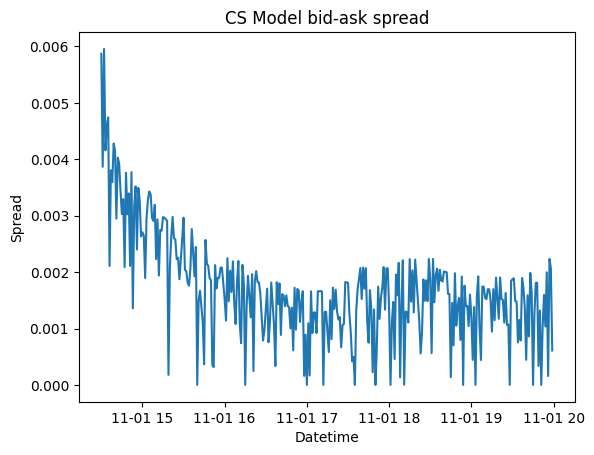

In [7]:
plt.figure()
plt.plot(result['Datetime'], result['CS'])
plt.xlabel('Datetime')
plt.ylabel('Spread')
plt.title('CS Model bid-ask spread')